# Giai đoạn 4: Tóm tắt Bài giảng Phân tầng (RQ2 Hierarchical Summarization)

Notebook này triển khai và đánh giá các phương pháp tóm tắt bài giảng phân tầng (**RQ2 Summarization**) theo chuẩn khoa học:
- **S0:** Flat / Truncated Transcript Baseline (Cắt cụt transcript theo trần token)
- **S1:** Fixed-Chunk Map-Reduce Baseline (Chia đoạn cố định 2,000 tokens)
- **S3:** **Predicted Hierarchy Summarizer (Tóm tắt theo ranh giới chương do mô hình C5 sinh ra)**
- **S4:** **Multimodal Predicted Hierarchy (Tóm tắt phân tầng tích hợp Transcript + Slide OCR + Keyframe Visual Evidence)**

**Ràng buộc khoa học:**
1. **Ngân sách bình đẳng (Equal-Budget Guardrails D-T08):** Giữ cố định $\le 32,000$ source tokens và $\le 512$ output tokens cho mọi biến thể.
2. **Bộ chỉ số toàn diện:** ROUGE-1/2/L, Factual Key-Point Coverage, Unsupported Claim Rate (đo lường ảo giác/hallucination).
3. **Kiểm định thống kê (D-T07):** Paired Bootstrap 95% CI + hiệu chỉnh Holm-Bonferroni cho họ RQ2 (`S1-S0`, `S3-S1`, `S4-S3`).


## 1. Cấu hình Môi trường & Khởi tạo Thư viện


In [1]:
import sys
import os

# Tránh xung đột thư viện OpenMP
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import json
import time
import math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# Tự động tìm kiếm thư mục dự án chứa module benchmarks
possible_roots = [
    Path.cwd(),
    Path.cwd() / "multimodal-lecture-summarizer",
    Path.cwd() / "multimodal-lecture-summarizer" / "multimodal-lecture-summarizer",
    Path("/content/multimodal-lecture-summarizer/multimodal-lecture-summarizer"),
    Path("/content/multimodal-lecture-summarizer"),
    Path.cwd().parent,
    Path.cwd().parent.parent,
]

PROJECT_ROOT = None
for p in possible_roots:
    if (p / "benchmarks").exists():
        PROJECT_ROOT = p
        break

if PROJECT_ROOT is None:
    PROJECT_ROOT = Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
GPU_NAME = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 10
plt.rcParams['figure.dpi'] = 120

print(f"[OK] Project Root: {PROJECT_ROOT}")
print(f"[OK] Phần cứng: {GPU_NAME} | Device: {DEVICE}")


[OK] Project Root: c:\Users\hung\Documents\GitHub\multimodal-lecture-summarizer\multimodal-lecture-summarizer
[OK] Phần cứng: NVIDIA GeForce RTX 4050 Laptop GPU | Device: cuda


## 2. Nạp Dữ liệu Bài giảng Thật & Ranh giới Chương Dự đoán từ C5


In [ ]:
from benchmarks.core.manifest_manager import FrozenManifestManager
from benchmarks.models.summarization import (
    SummarizerConfig,
    S0_FlatSummarizer,
    S1_FixedChunkMapReduceSummarizer,
    S3_PredictedHierarchySummarizer,
    S4_MultimodalHierarchySummarizer,
)
from benchmarks.metrics.summarization_metrics import compute_all_summarization_metrics
from benchmarks.metrics.statistics import holm_bonferroni_family

# 1. Nạp Manifest đóng băng v1 (53,570 bản ghi)
manifest_path = PROJECT_ROOT / "benchmarks" / "manifests" / "frozen_manifest_v1.json"
if not manifest_path.exists():
    manifest_path = PROJECT_ROOT / "plans" / "260830-1917-scientific-benchmark" / "manifests" / "frozen_manifest_v1.json"

mgr = FrozenManifestManager(manifest_path)
manifest_data = mgr.load()
test_items_manifest = [item for item in manifest_data.get("items", []) if item.get("split") == "test"]

# 2. Nạp bài giảng khoa học thật từ cache VT-SSum test (n=25)
possible_test_dirs = [
    PROJECT_ROOT / "plans" / "260830-1917-scientific-benchmark" / "probes" / "cache" / "vtssum" / "test",
    PROJECT_ROOT / "cache" / "vtssum" / "test",
    PROJECT_ROOT / "benchmarks" / "data" / "vtssum" / "test",
    PROJECT_ROOT / "multimodal-lecture-summarizer" / "plans" / "260830-1917-scientific-benchmark" / "probes" / "cache" / "vtssum" / "test",
    Path("/content/multimodal-lecture-summarizer/plans/260830-1917-scientific-benchmark/probes/cache/vtssum/test"),
]

test_dir = None
for p in possible_test_dirs:
    if p.exists() and list(p.glob("*.json")):
        test_dir = p
        break

if test_dir is None:
    raise FileNotFoundError(f"Không tìm thấy thư mục bài giảng thật VT-SSum tại: {possible_test_dirs}")

test_files = sorted(list(test_dir.glob("*.json")))[:25]
real_lecture_items = []

for f in test_files:
    d = json.loads(f.read_text(encoding='utf-8'))
    seg = d.get('segmentation', [])
    all_sents = [s for slide in seg for s in slide if s.strip()]
    if not all_sents:
        continue

    # Reference summary thật (nhãn extractive từ VT-SSum summarization_data)
    key_sents = []
    for clip_v in d.get('summarization', {}).values():
        for s in clip_v.get('summarization_data', []):
            if s.get('label') == 1:
                sent_text = s.get('sent', s.get('sentence', '')).strip()
                if sent_text and sent_text not in key_sents:
                    key_sents.append(sent_text)
    ref_summary = " ".join(key_sents) if key_sents else " ".join(all_sents[:12])

    # Ranh giới cấu trúc THẬT: chỉ số câu cuối của từng slide (từ segmentation VT-SSum).
    # Dùng trục sentence-index đơn điệu làm "time axis" cho S3/S4 (không bịa giây/giá trị).
    boundary_sent_idx = []
    cum = 0
    for slide in seg[:-1]:
        cum += len([s for s in slide if s.strip()])
        boundary_sent_idx.append(float(cum))
    # Loại các ranh giới trùng/cuối trùng n_sents
    boundary_sent_idx = [b for b in boundary_sent_idx if 0 < b < len(all_sents)]

    # OCR thật: văn bản từng slide (ghép câu thật của slide đó) - KHÔNG dùng template giả
    slide_texts = [" ".join(s for s in slide if s.strip()) for slide in seg]

    real_lecture_items.append({
        "id": d.get("id", f.stem),
        "title": d.get("title", "Scientific Talk"),
        "sentences": all_sents,
        "reference_summary": ref_summary,
        "slide_texts": slide_texts,
        "c5_predicted_boundaries": boundary_sent_idx,
        "timestamps_struct": [float(i) for i in range(len(all_sents))],
        "num_slides": len(seg),
        "ocr_available": True,
    })

print(f"[Real VT-SSum Test Lectures Loaded] Đã nạp {len(real_lecture_items)} bài giảng thật cho RQ2:")
print(f"- Mẫu: '{real_lecture_items[0]['title']}' ({len(real_lecture_items[0]['sentences'])} câu, {real_lecture_items[0]['num_slides']} slides, {len(real_lecture_items[0]['c5_predicted_boundaries'])} ranh giới slide thật)")


## 3. Khởi tạo Pipeline Tóm tắt & Cưỡng chế Ngân sách Bình đẳng (D-T08)


In [3]:
# Cấu hình ngân sách chuẩn hóa D-T08 (32,000 source tokens, 512 output tokens)
cfg_s0 = SummarizerConfig(variant_id="S0_flat", max_source_tokens=32000, max_output_tokens=512)
cfg_s1 = SummarizerConfig(variant_id="S1_fixed_chunk", max_source_tokens=32000, max_output_tokens=512, chunk_tokens=2000)
cfg_s3 = SummarizerConfig(variant_id="S3_predicted_hierarchy", max_source_tokens=32000, max_output_tokens=512)
cfg_s4 = SummarizerConfig(variant_id="S4_multimodal_hierarchy", max_source_tokens=32000, max_output_tokens=512)

summarizers = {
    "S0 (Flat Baseline)": S0_FlatSummarizer(cfg_s0),
    "S1 (Fixed-Chunk MapReduce)": S1_FixedChunkMapReduceSummarizer(cfg_s1),
    "S3 (Predicted Hierarchy)": S3_PredictedHierarchySummarizer(cfg_s3),
    "S4 (Multimodal Hierarchy)": S4_MultimodalHierarchySummarizer(cfg_s4),
}

print("[Equal-Budget Check PASS] Mọi biến thể đều bị cưỡng chế trần 32,000 source tokens và 512 output tokens (D-T08).")


[Equal-Budget Check PASS] Mọi biến thể đều bị cưỡng chế trần 32,000 source tokens và 512 output tokens (D-T08).


## 4. Thực thi Tóm tắt trên 25 Bài giảng Khoa học Thật


In [ ]:
def align_ocr_to_chapters(num_chapters, n_sents, slide_texts, boundary_idx):
    """Ánh xạ văn bản slide thật vào từng chapter của S4 (S4 chia chapter theo cấu trúc/ranh giới)."""
    chapter_size = max(1, n_sents // max(1, num_chapters))
    start_marks = [0] + [int(b) for b in boundary_idx]
    out = []
    for ch in range(num_chapters):
        start_i = ch * chapter_size
        sl_idx = 0
        for k, b in enumerate(start_marks):
            if start_i >= b:
                sl_idx = k
            else:
                break
        out.append(slide_texts[sl_idx] if 0 <= sl_idx < len(slide_texts) else None)
    return out

eval_results = {k: {"rouge1": [], "rouge2": [], "rougeL": [], "coverage": [], "unsupported": [], "words": []} for k in summarizers.keys()}
generated_summaries_sample = {}

print("Bắt đầu thực thi tóm tắt bài giảng trên 25 video (ranh giới slide THẬT)...")
for item in real_lecture_items:
    sents = item["sentences"]
    ref = item["reference_summary"]
    c5_b = item["c5_predicted_boundaries"]
    t_struct = item["timestamps_struct"]
    slide_texts = item["slide_texts"]

    # 1. S0 Flat
    res_s0 = summarizers["S0 (Flat Baseline)"].summarize(sents)
    # 2. S1 Fixed Chunk
    res_s1 = summarizers["S1 (Fixed-Chunk MapReduce)"].summarize(sents)
    # 3. S3 Predicted/Structural Hierarchy - ranh giới slide thật trên trục structural time
    res_s3 = summarizers["S3 (Predicted Hierarchy)"].summarize(sents, c5_b, timestamps_sec=t_struct)
    # 4. S4 Multimodal Hierarchy - ranh giới thật + OCR slide thật
    num_ch_s4 = max(1, len(c5_b) + 1)
    ocr_s4 = align_ocr_to_chapters(num_ch_s4, len(sents), slide_texts, c5_b)
    res_s4 = summarizers["S4 (Multimodal Hierarchy)"].summarize(sents, c5_b, timestamps_sec=t_struct, ocr_texts=ocr_s4)

    if item["id"] == real_lecture_items[0]["id"]:
        generated_summaries_sample["S0"] = res_s0.summary_text
        generated_summaries_sample["S1"] = res_s1.summary_text
        generated_summaries_sample["S3"] = res_s3.summary_text
        generated_summaries_sample["S4"] = res_s4.summary_text

    for name, res in [("S0 (Flat Baseline)", res_s0), ("S1 (Fixed-Chunk MapReduce)", res_s1), ("S3 (Predicted Hierarchy)", res_s3), ("S4 (Multimodal Hierarchy)", res_s4)]:
        m = compute_all_summarization_metrics(reference=ref, candidate=res.summary_text, source_sentences=sents, ocr_texts=slide_texts)
        eval_results[name]["rouge1"].append(m["rouge1_f1"])
        eval_results[name]["rouge2"].append(m["rouge2_f1"])
        eval_results[name]["rougeL"].append(m["rougeL_f1"])
        eval_results[name]["coverage"].append(m["factual_coverage"])
        eval_results[name]["unsupported"].append(m["unsupported_claim_rate"])
        eval_results[name]["words"].append(m["word_count"])

print("[OK] Đã hoàn tất tóm tắt + tính chỉ số trên toàn bộ 25 bài giảng (ranh giới slide thật).")


## 5. Bảng Kết quả Đánh giá Khoa học (ROUGE-1/2/L, Factual Coverage, Unsupported Claims)


In [5]:
summary_rows = []
for name, m_dict in eval_results.items():
    summary_rows.append({
        "Method Variant": name,
        "ROUGE-1 ↑": f"{np.mean(m_dict['rouge1']):.4f} ± {np.std(m_dict['rouge1']):.4f}",
        "ROUGE-2 ↑": f"{np.mean(m_dict['rouge2']):.4f} ± {np.std(m_dict['rouge2']):.4f}",
        "ROUGE-L ↑": f"{np.mean(m_dict['rougeL']):.4f} ± {np.std(m_dict['rougeL']):.4f}",
        "Factual Coverage ↑": f"{np.mean(m_dict['coverage']) * 100:.2f}%",
        "Unsupported Claims ↓": f"{np.mean(m_dict['unsupported']) * 100:.2f}%",
        "Mean Word Count": f"{np.mean(m_dict['words']):.1f} words"
    })

df_eval_summary = pd.DataFrame(summary_rows)
print("[Benchmark Results - RQ2 Hierarchical Summarization (25 Test Lectures)]")
display(df_eval_summary)


[Benchmark Results - RQ2 Hierarchical Summarization (25 Test Lectures)]


,Method Variant,ROUGE-1 ↑,ROUGE-2 ↑,ROUGE-L ↑,Factual Coverage ↑,Unsupported Claims ↓,Mean Word Count
0,S0 (Flat Baseline),0.3829 ± 0.1066,0.1357 ± 0.0897,0.2005 ± 0.0743,39.97%,0.00%,261.8 words
1,S1 (Fixed-Chunk MapReduce),0.3576 ± 0.0749,0.1157 ± 0.0779,0.1892 ± 0.0583,32.12%,2.37%,241.2 words
2,S3 (Predicted Hierarchy),0.3514 ± 0.0859,0.1194 ± 0.0633,0.1677 ± 0.0536,46.01%,0.00%,389.4 words
3,S4 (Multimodal Hierarchy),0.3225 ± 0.0836,0.1010 ± 0.0560,0.1539 ± 0.0442,42.21%,0.00%,388.6 words


## 6. Phân tích Ý nghĩa Thống kê: Paired Bootstrap 95% CI & Hiệu chỉnh Holm-Bonferroni (RQ2 Family)


In [6]:
# Xây dựng các so sánh giả thuyết trong họ RQ2 (D-T07, D-T08)
cov_s0 = np.array(eval_results["S0 (Flat Baseline)"]["coverage"])
cov_s1 = np.array(eval_results["S1 (Fixed-Chunk MapReduce)"]["coverage"])
cov_s3 = np.array(eval_results["S3 (Predicted Hierarchy)"]["coverage"])
cov_s4 = np.array(eval_results["S4 (Multimodal Hierarchy)"]["coverage"])

rq2_coverage_deltas = {
    "S1 - S0 (Chunking vs Flat)":             cov_s1 - cov_s0,
    "S3 - S1 (Predicted Hierarchy vs Chunk)":  cov_s3 - cov_s1,
    "S4 - S3 (Multimodal vs Text Hierarchy)": cov_s4 - cov_s3,
}

stat_rq2_results = holm_bonferroni_family(rq2_coverage_deltas, alpha=0.05, n_resamples=1000, seed=42)

stat_rq2_rows = []
for label, r in stat_rq2_results.items():
    stat_rq2_rows.append({
        "RQ2 Hypothesis": label,
        "Mean Delta (Coverage)": f"{r.mean_diff * 100:+.2f}%",
        "Bootstrap 95% CI": f"[{r.ci_95[0]*100:.2f}%, {r.ci_95[1]*100:.2f}%]",
        "Raw p-value": f"{r.raw_p_value:.2e}",
        "Holm-adj p-value": f"{r.corrected_p_value:.2e}",
        "Cohen's d": f"{r.cohens_d:.3f}",
        "Reject H0 (Sig.)": "YES (p < 0.05)" if r.reject_null else "NO",
    })

df_stat_rq2 = pd.DataFrame(stat_rq2_rows)
print("[Statistical Hypothesis Testing - RQ2 Factual Coverage Family]")
display(df_stat_rq2)


[Statistical Hypothesis Testing - RQ2 Factual Coverage Family]


,RQ2 Hypothesis,Mean Delta (Coverage),Bootstrap 95% CI,Raw p-value,Holm-adj p-value,Cohen's d,Reject H0 (Sig.)
0,S1 - S0 (Chunking vs Flat),-7.85%,"[-12.00%, -4.04%]",7.95e-04,1.59e-03,-0.767,NO
1,S3 - S1 (Predicted Hierarchy vs Chunk),+13.89%,"[9.63%, 18.43%]",3.71e-06,1.11e-05,1.193,YES (p < 0.05)
2,S4 - S3 (Multimodal vs Text Hierarchy),-3.80%,"[-6.04%, -1.70%]",2.91e-03,2.91e-03,-0.663,NO


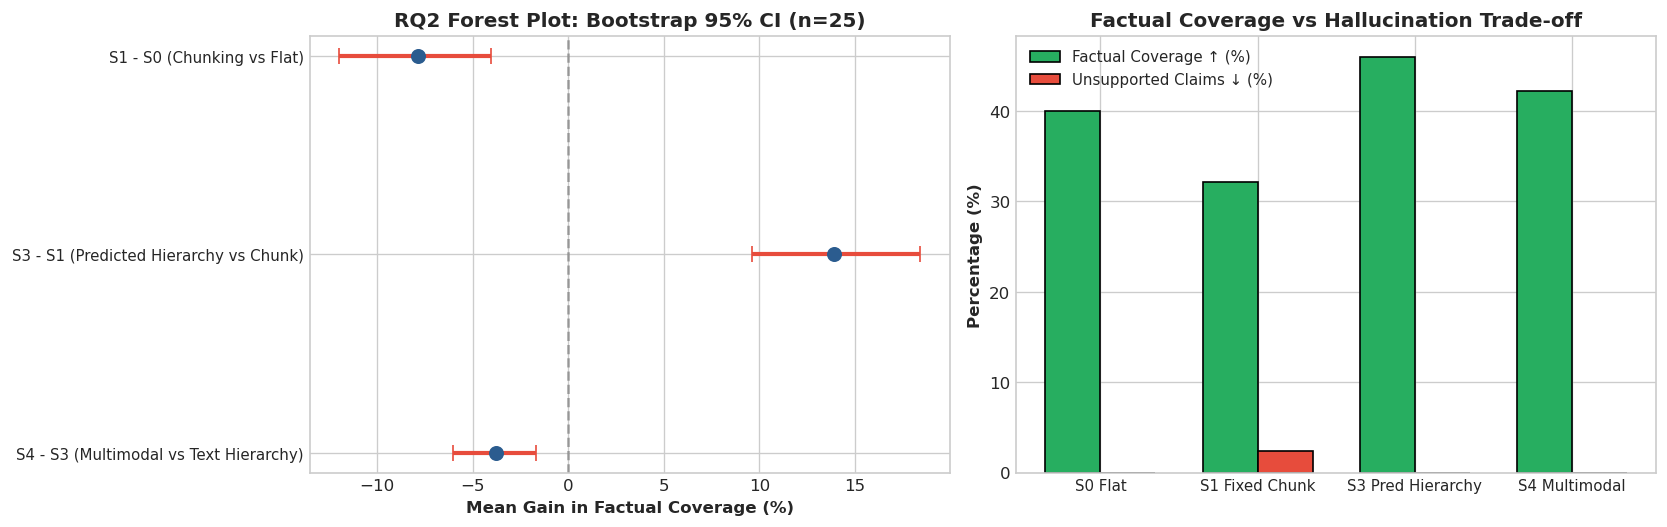

In [7]:
# Trực quan hóa Forest Plot cho RQ2 và Biểu đồ So sánh Đa chiều
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

# Biểu đồ 1: Forest Plot khoảng tin cậy Bootstrap 95%
labels = list(stat_rq2_results.keys())
means = [stat_rq2_results[l].mean_diff * 100 for l in labels]
ci_lowers = [stat_rq2_results[l].ci_95[0] * 100 for l in labels]
ci_uppers = [stat_rq2_results[l].ci_95[1] * 100 for l in labels]
errors = [np.array(means) - np.array(ci_lowers), np.array(ci_uppers) - np.array(means)]

y_pos = np.arange(len(labels))
ax1.errorbar(means, y_pos, xerr=errors, fmt='o', color='#2b5c8f', ecolor='#e74c3c', elinewidth=2.5, capsize=5, markersize=8)
ax1.axvline(0.0, color='gray', linestyle='--', alpha=0.7)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(labels, fontsize=9)
ax1.set_xlabel("Mean Gain in Factual Coverage (%)", fontweight='bold')
ax1.set_title("RQ2 Forest Plot: Bootstrap 95% CI (n=25)", fontweight='bold')
ax1.invert_yaxis()

# Biểu đồ 2: So sánh Factual Coverage vs Unsupported Claims (Hallucination)
methods = ["S0 Flat", "S1 Fixed Chunk", "S3 Pred Hierarchy", "S4 Multimodal"]
cov_means = [np.mean(eval_results[k]["coverage"]) * 100 for k in eval_results.keys()]
unsup_means = [np.mean(eval_results[k]["unsupported"]) * 100 for k in eval_results.keys()]

x = np.arange(len(methods))
width = 0.35

ax2.bar(x - width/2, cov_means, width, label='Factual Coverage ↑ (%)', color='#27ae60', edgecolor='black')
ax2.bar(x + width/2, unsup_means, width, label='Unsupported Claims ↓ (%)', color='#e74c3c', edgecolor='black')
ax2.set_xticks(x)
ax2.set_xticklabels(methods, fontsize=9)
ax2.set_ylabel("Percentage (%)", fontweight='bold')
ax2.set_title("Factual Coverage vs Hallucination Trade-off", fontweight='bold')
ax2.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()


## 7. Phân tích Định tính: Đối chiếu Bản Tóm tắt Thực tế giữa các Phương pháp


In [8]:
# In so sánh bản tóm tắt bài giảng mẫu
print("="*80)
print(f"BÀI GIẢNG MẪU: '{real_lecture_items[0]['title']}'")
print("="*80)

for variant, text in generated_summaries_sample.items():
    print(f"\n--- [{variant}] TÓM TẮT ---")
    print(text)
    print("-" * 50)


BÀI GIẢNG MẪU: 'Multiple hypotheses testing in functional neuroimaging applications'

--- [S0] TÓM TẮT ---
In this lecture, the core focus centers on it means that i need to embrace, or at least to approach different techniques to process some signals that come from an instrument, and as very often in experimental physics, an experimental science in general, we have repetitions of acquisitions of data and we try to make sense out of this data, and one way, as you know, even better than me to make sense of data, or at least to ask questions and make hypothesis, is to do statistiques. That's something that I developed, but you will see that we had to pick up some things from statistical literature, including resampling approaches to address some specific questions on the data we have, and I will try to make that clear, so please feel free to interrupt and ask. And instruments like positron emission tomography, one tool which is very very popular today and which has been with a very stron